MATH2603 Group Project

Project Overview: California Housing Price Prediction using Neural Networks

The objective of this project is to build a neural network model for predicting house prices using the California Housing dataset.
The project begins by establishing a baseline neural network model that makes predictions using only the raw data features.
Subsequently, by constructing neighbourhood-based features and utilising k-nearest neighbours (kNN) to extract additional information based on geographical proximity, an enhanced model is built to improve predictive performance.

Note: This project takes a relatively long time to run, approximately 15 to 55 minutes, with the exact duration depending on the environment configuration and computer performance. Removing the code for the parameter optimisation process can significantly reduce the running time; you may run the first, second and fourth sections of Part One, as well as the final code block in Part Three, directly.

Visualisation of results in the project
   - Plot Validation MSE for Different Architectures and Activations
   - Plot Validation MSE for Feature Combinations
   - Plot Validation MSE vs Number of Neighbours (Single Neighbourhood Features)
   - Plot Train vs Validation MSE — Model 1 and Model 2
   - Plot Learning Curves — Validation-stage Generalisation Check
   - Plot Absolute Error vs Actual Price

PART ONE

Data Import and Preprocessing
   - Loading the California Housing dataset
   - Handling missing values
   - Standardising the data
   - Splitting the dataset into training, validation and test sets

In [2]:
#数据导入及处理缺失值
#Data import and handling of missing values
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

# 加载数据
# load data
data = fetch_california_housing()

X = data.data          # 特征值eigenvalue
y = data.target        # 目标值（房价）Target value (house price)

feature_names = data.feature_names

# Transfer to DataFrame（推荐，方便后续操作）
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name="MedHouseVal")

print(X.head())
print(y.head())
print("Shape of X:", X.shape)

# ===== 处理缺失值 =====
#Handling Missing Values
print("Missing values before cleaning:")
print(X.isnull().sum())

# 删除含缺失值的行（如果有）
# Delete rows with missing values (if any).
X = X.dropna()
y = y.loc[X.index]   # 保持 X 和 y 对齐 Align X and Y

print("Shape after removing missing values:", X.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64
Shape of X: (20640, 8)
Missing values before cleaning:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Shape after removing missing values: (20640, 8)


In [3]:
#数据标准化和划分训练集，验证集和测试集
# Data standardization and division of training set, validation set and test set

#Data preprocessing and division of training，validation and test set
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# 先从X特征值，y房价 中分出 test 和 train_val两个数据集
# First, separate the "X feature values" and "y house prices" into two datasets: "test" and "train_val".
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=26
)
# X_train_val → 80% 的特征，X_test → 20% 的特征，y_train_val → 80% 的标签，y_test → 20% 的标签
# X_train_val → 80% of the features, X_test → 20% of the features, 
# y_train_val → 80% of the labels, y_test → 20% of the labels

# 从X_train_val, y_train_val里再分 validation（分成X_train, X_val, y_train, y_val）
# From X_train_val and y_train_val, further divide into validation (resulting in X_train, X_val, y_train, y_val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=26
)#这里的0.1是train_val80%里的10%
#Here, 0.1 refers to the 10% within the "train_val 80%" portion.


# 在标准化前，先保存 raw（未标准化）版本：后面kNN需要用原始经纬度
# Before standardization, save the raw (unstandardized) version first: 
# the kNN algorithm later will require the original latitude and longitude values.
X_train_raw = X_train.copy()
X_val_raw   = X_val.copy()
X_test_raw  = X_test.copy()

# scale (fit only on train) and then convert it back to a DataFrame#标准化（只在训练集）并转回DataFrame
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns,index=X_train_raw.index)
X_val   = pd.DataFrame(scaler.transform(X_val), columns=X.columns,index=X_val_raw.index)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test_raw.index)
#scaler.transform 标准化 test 数据 means to Standardized test data
#index=X_test_raw.index Pandas 会默认生成新的 0~n 索引 Pandas will automatically generate new indices ranging from 0 to n.
#Add index=...，这样索引不会乱（对齐 y / 后面 debug 更稳）so the index won't be disordered (it will be more stable when aligning y / and then the debug part).

PART TWO

Baseline Neural Network
   - Build a feedforward neural network
   - Experiment with different hidden layer structures and activation functions
   - Select the optimal model parameters using the validation set
   - Combine the training and validation datasets to select the optimal hidden layer structure and activation functions, and train the `baseline_final_model`


Architecture: (32,), Activation: tanh, Validation MSE: 0.3137
Architecture: (32,), Activation: relu, Validation MSE: 0.3262
Architecture: (32,), Activation: logistic, Validation MSE: 0.3210
Architecture: (64,), Activation: tanh, Validation MSE: 0.3140
Architecture: (64,), Activation: relu, Validation MSE: 0.3272
Architecture: (64,), Activation: logistic, Validation MSE: 0.3120
Architecture: (64, 32), Activation: tanh, Validation MSE: 0.2841
Architecture: (64, 32), Activation: relu, Validation MSE: 0.2890
Architecture: (64, 32), Activation: logistic, Validation MSE: 0.3078
Architecture: (128, 32), Activation: tanh, Validation MSE: 0.2789
Architecture: (128, 32), Activation: relu, Validation MSE: 0.2796
Architecture: (128, 32), Activation: logistic, Validation MSE: 0.2899
Architecture: (128, 64), Activation: tanh, Validation MSE: 0.2798
Architecture: (128, 64), Activation: relu, Validation MSE: 0.2793
Architecture: (128, 64), Activation: logistic, Validation MSE: 0.2855
Architecture: (12

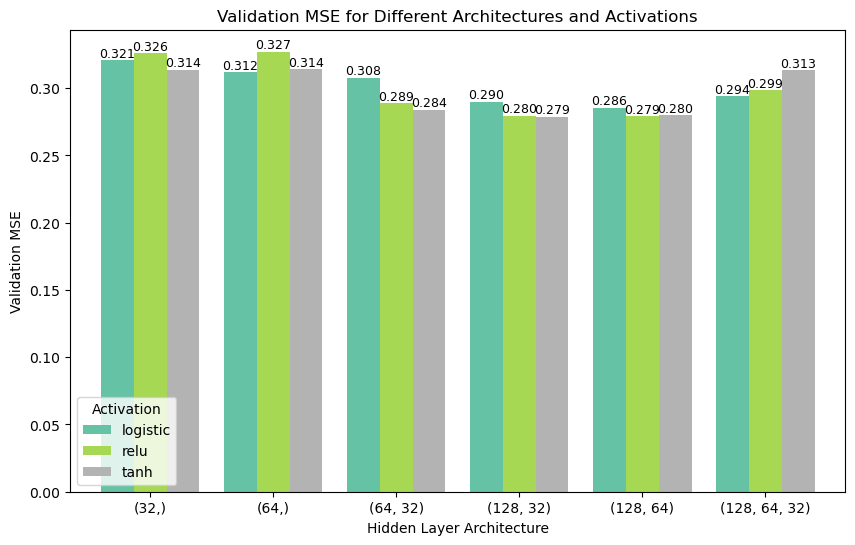

In [8]:
#寻找最优隐藏层与激活函数
#Search for the optimal hidden layer and activation function
import matplotlib.pyplot as plt
# 1) Define architectures and activation functions
#  定义不同的神经网络结构和激活函数
# ============================================================

# Each tuple represents the number of neurons in hidden layers.
# Example:
# (64,32) means two hidden layers with 64 and 32 neurons.
# 每个元组表示隐藏层结构。
# 例如：
# (64,32) 表示两个隐藏层，分别有 64 和 32 个神经元。
architectures = [
    (32,),
    (64,),
    (64,32),
    (128,32),
    (128,64),
    (128,64,32)
]

# Activation functions to test.
# tanh  → nonlinear symmetric activation
# relu  → widely used deep learning activation
# logistic → sigmoid nonlinear activation
# 要测试的激活函数：
# tanh → 对称的非线性函数
# relu → 深度学习中常用激活函数
# logistic → Sigmoid 非线性激活函数
activations = ['tanh', 'relu', 'logistic']


# ============================================================
# 2) Train models and collect Validation MSE
# 训练模型并记录验证集 MSE
# ============================================================
arch_search_results = []

for arch in architectures:
    for act in activations:

        # Create a neural network model with the current architecture and activation function.
        # 创建一个神经网络模型，使用当前的隐藏层结构和激活函数
        arch_model = MLPRegressor(
            hidden_layer_sizes=arch,
            activation=act,
            solver='adam',
            learning_rate_init=1e-3,
            max_iter=800,
            early_stopping=False,
            random_state=26
        )

        # Train the model on the training dataset.
        # 在训练集上训练模型
        arch_model.fit(X_train, y_train)

        # Predict house prices on the validation set
        # 在验证集上进行预测
        arch_val_pred = arch_model.predict(X_val)
        # Calculate the Mean Squared Error (MSE) on the validation set
        # 计算验证集上的均方误差（MSE）
        arch_val_mse = mean_squared_error(y_val, arch_val_pred) 

        arch_search_results.append({
            'Architecture': str(arch),
            'Activation': act,
            'Validation_MSE': arch_val_mse
        })

        print(f"Architecture: {arch}, Activation: {act}, Validation MSE: {arch_val_mse:.4f}")

# ============================================================
# 3) Convert results to DataFrame
# 将结果转换为表格
# Convert the results list into a pandas DataFrame
# and reshape it using pivot for easier visualization.
# 将实验结果转换为 DataFrame，
# 再使用 pivot 变成适合绘图的格式。

results_df = pd.DataFrame(arch_search_results)

pivot_table = results_df.pivot(
    index='Architecture',
    columns='Activation',
    values='Validation_MSE'
)

# -------------------------------------------------
# Arrange the architecture according to the complexity of the hidden layers
# 按隐藏层的复杂程度进行排列架构
# -------------------------------------------------

order = ['(32,)', '(64,)', '(64, 32)', '(128, 32)','(128, 64)', '(128, 64, 32)']
pivot_table = pivot_table.reindex(order)

print("\n=== Validation MSE Table ===")
print(pivot_table)


# ============================================================
# 4) Plot grouped bar chart
#  绘制分组柱状图
# Create a grouped bar chart showing Validation MSE for each
# architecture and activation combination.
# 绘制分组柱状图，
# 展示不同隐藏层结构和激活函数组合的 Validation MSE。

ax = pivot_table.plot(
    kind='bar',
    figsize=(10,6),
    width=0.8,
    colormap='Set2'
)

plt.ylabel("Validation MSE")
plt.xlabel("Hidden Layer Architecture")
plt.title("Validation MSE for Different Architectures and Activations")
plt.xticks(rotation=0)
plt.legend(title="Activation")




# ------------------------------------------------------------
# Add value labels above bars using patches
# 使用 patches 自动获取每个柱子的位置，避免坐标误差
# ------------------------------------------------------------
    # Place text at the center top of each bar
    # 在每个柱子的顶部中心位置标注数值

# Add value labels above bars
for p in ax.patches:
    height = p.get_height()# 获取柱子的高度（MSE值）Get bar height (MSE value)
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()

In [4]:
# Final baseline neural network Training
# 合并Train & Validation 数据集选择最优隐藏层结构与激活函数训练baseline_final_model模型
# Merge the Train and Validation datasets, 
# select the optimal hidden layer structure and activation function, and train the baseline_final_model model.

# 1) Combine original train and validation sets
#    合并原来的训练集和验证集
X_train_final_raw_base = pd.concat([X_train_raw, X_val_raw], axis=0)
y_train_final_base = pd.concat([y_train, y_val], axis=0)

# Make sure indices align
# 保证索引一致
X_train_final_raw_base = X_train_final_raw_base.sort_index()
y_train_final_base = y_train_final_base.loc[X_train_final_raw_base.index]

# Refit scaler on the final baseline training set
scaler_base_final = StandardScaler()

X_train_final_base = pd.DataFrame(
    scaler_base_final.fit_transform(X_train_final_raw_base),
    columns=X_train_final_raw_base.columns,
    index=X_train_final_raw_base.index
)

X_test_final_base = pd.DataFrame(
    scaler_base_final.transform(X_test_raw),
    columns=X_test_raw.columns,
    index=X_test_raw.index
)

# model (no internal early stopping, since you already have X_val)
baseline_final_model = MLPRegressor(
    hidden_layer_sizes=(128,32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=800,
    early_stopping=False,
    random_state=26
)

baseline_final_model.fit(X_train_final_base, y_train_final_base)

#预测集的预测
#The predictions of the prediction set
baseline_test_pred = baseline_final_model.predict(X_test_final_base)
# 训练集预测
#Training set prediction
baseline_train_pred = baseline_final_model.predict(X_train_final_base)

# 计算训练误差
# Calculate training error
baseline_train_mse = mean_squared_error(y_train_final_base, baseline_train_pred)
baseline_test_mse_final = mean_squared_error(y_test, baseline_test_pred)

print("Final Baseline Train MSE:", baseline_train_mse)#加入是为了判断是不是欠拟合或者过拟合Joining is to determine whether it is underfitting or overfitting.
print("Final Baseline Test MSE:", baseline_test_mse_final)

Final Baseline Train MSE: 0.23981524417887298
Final Baseline Test MSE: 0.24851482842267858


PART THREE

Enhanced Model (Neighbourhood Features)
   - Construct neighbourhood relationships using k-nearest neighbours (kNN)
   - Extract statistical features of neighbourhood scores from neighbouring samples
   - Investigate the impact of different numbers of neighbourhood features on Val MSE
   - Investigate the impact of the same number of neighbourhood features versus different k-values on Val MSE
   - Incorporate the optimal neighbourhood features into the original features and retrain the model
   - Merge the training and validation datasets to select the optimal neighbourhood features and k-value for training the model_enh_final model

### Model 2: Neighbourhood-Based Features

This section constructs neighbourhood-based features using the **k-nearest neighbours (kNN)** algorithm based on latitude and longitude.

The kNN model is fitted using the **training coordinates only**, so that neighbourhood statistics are computed solely from training data and data leakage is avoided.

A helper function `neighbour_summary_feature()` is defined to compute summary statistics of neighbour prices.  
For each observation, the prices of its **K nearest neighbours** are used to calculate five statistics: **mean, median, minimum, maximum, and range**.

When generating features for the training set, the observation itself is excluded from its neighbour set.

In [10]:
# Model 2: Add neighbourhood-based features

from sklearn.neighbors import NearestNeighbors

K = 7  # Number of nearest neighbours used to construct neighbourhood features


#   Fit kNN using training coordinates only, this ensures neighbourhood features are constructed 
#   solely from training data and avoids data leakage.
knn = NearestNeighbors(n_neighbors=K + 1)
knn.fit(X_train_raw[['Latitude', 'Longitude']])

# Align y_train with X_train_raw so neighbour indices correctly map to prices
y_train_aligned = y_train.loc[X_train_raw.index].to_numpy()



# Define a function to compute neighbourhood price statistics
# 这部分是用来计算第一个图所需要的数据
def neighbour_summary_feature(query_df, summary="mean", exclude_self=False):
    # Find nearest neighbours based on geographic coordinates
    _, inds = knn.kneighbors(query_df[['Latitude', 'Longitude']])

    values = []

    # Loop through each sample and compute the summary statistic
    for row_i, idxs in enumerate(inds):

        if exclude_self:
            # Remove the sample itself if it appears in neighbours
            idxs = idxs[idxs != row_i]

            # Keep exactly K neighbours
            idxs = idxs[:K]

        else:
            # Validation/test samples are not part of training set
            # so we directly take the first K neighbours
            idxs = idxs[:K]

        # Retrieve neighbour prices
        neigh_prices = y_train_aligned[idxs]

        if summary == "mean":
            values.append(np.mean(neigh_prices))

        elif summary == "median":
            values.append(np.median(neigh_prices))

        elif summary == "min":
            values.append(np.min(neigh_prices))

        elif summary == "max":
            values.append(np.max(neigh_prices))

        elif summary == "range":
            values.append(np.max(neigh_prices) - np.min(neigh_prices))

        else:
            raise ValueError("summary must be one of: mean, median, min, max, range")

    return np.array(values)



# Neighbourhood mean price 
neigh_price_mean_train = neighbour_summary_feature(X_train_raw, summary="mean", exclude_self=True)
neigh_price_mean_val   = neighbour_summary_feature(X_val_raw, summary="mean", exclude_self=False)
neigh_price_mean_test  = neighbour_summary_feature(X_test_raw, summary="mean", exclude_self=False)

# Neighbourhood median price 
neigh_price_median_train = neighbour_summary_feature(X_train_raw, summary="median", exclude_self=True)
neigh_price_median_val   = neighbour_summary_feature(X_val_raw, summary="median", exclude_self=False)
neigh_price_median_test  = neighbour_summary_feature(X_test_raw, summary="median", exclude_self=False)

# Neighbourhood minimum price 
neigh_price_min_train = neighbour_summary_feature(X_train_raw, summary="min", exclude_self=True)
neigh_price_min_val   = neighbour_summary_feature(X_val_raw, summary="min", exclude_self=False)
neigh_price_min_test  = neighbour_summary_feature(X_test_raw, summary="min", exclude_self=False)

# Neighbourhood maximum price 
neigh_price_max_train = neighbour_summary_feature(X_train_raw, summary="max", exclude_self=True)
neigh_price_max_val   = neighbour_summary_feature(X_val_raw, summary="max", exclude_self=False)
neigh_price_max_test  = neighbour_summary_feature(X_test_raw, summary="max", exclude_self=False)

# Neighbourhood price range 
neigh_price_range_train = neighbour_summary_feature(X_train_raw, summary="range", exclude_self=True)
neigh_price_range_val   = neighbour_summary_feature(X_val_raw, summary="range", exclude_self=False)
neigh_price_range_test  = neighbour_summary_feature(X_test_raw, summary="range", exclude_self=False)

### Baseline Validation Performance

A baseline neural network model is first trained using only the original features.  
Inputs are standardised using `StandardScaler`, and the **validation MSE** is computed as a reference for later comparisons.


In [11]:
### 用于计算合并之前的baseline validation MSE的函数 
# 后面用到的baseline model都是这个，就不用繁琐的每次都写了
scaler_base = StandardScaler()

X_train_base = scaler_base.fit_transform(X_train_raw)
X_val_base = scaler_base.transform(X_val_raw)

baseline_model = MLPRegressor(
    hidden_layer_sizes=(128, 32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=800,
    early_stopping=False,
    random_state=26
)

#计算后续需要的baseline validation MSE
baseline_model.fit(X_train_base, y_train)
baseline_val_pred = baseline_model.predict(X_val_base)
baseline_val_mse = mean_squared_error(y_val, baseline_val_pred)

### Neighbourhood Feature Combination Experiments

In addition to evaluating individual neighbourhood features, this section tests **combinations of multiple neighbourhood statistics**.

A helper function is used to add selected neighbourhood features to the original dataset, re-standardise the inputs, train the neural network, and compute the **validation MSE**.

All possible **1-feature, 2-feature, and 3-feature combinations** are evaluated.  
The results are collected in a table to analyse how the number and type of neighbourhood features affect model performance.

In [12]:
# Evaluate combinations of neighbourhood-based features
# This section tests multiple feature combinations

from itertools import combinations
import pandas as pd


# Store neighbourhood features for training and validation sets
feature_pool_train = {
    "Mean": neigh_price_mean_train,
    "Median": neigh_price_median_train,
    "Min": neigh_price_min_train,
    "Max": neigh_price_max_train,
    "Range": neigh_price_range_train
}

feature_pool_val = {
    "Mean": neigh_price_mean_val,
    "Median": neigh_price_median_val,
    "Min": neigh_price_min_val,
    "Max": neigh_price_max_val,
    "Range": neigh_price_range_val
}



# Add multiple neighbourhood features and compute validation MSE
def run_multi_features(feature_dict_train, feature_dict_val):

    # Copy original datasets to avoid modifying them
    Xtr = X_train_raw.copy()
    Xva = X_val_raw.copy()

    # Add selected neighbourhood features
    for col, arr in feature_dict_train.items():
        Xtr[col] = arr

    for col, arr in feature_dict_val.items():
        Xva[col] = arr

    # Re-standardise inputs
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xva_s = sc.transform(Xva)

    # Train model and compute validation MSE
    baseline_model.fit(Xtr_s, y_train)
    baseline_val_pred  = baseline_model.predict(Xva_s)

    return mean_squared_error(y_val, baseline_val_pred)


# Evaluate different feature combinations
def evaluate_feature_combinations(
    feature_pool_train,
    feature_pool_val,
    combo_sizes=None,
    selected_combos=None
):

    feature_names = list(feature_pool_train.keys())
    combo_neighbour_results = []

    # Generate combinations automatically if not specified
    if selected_combos is not None:
        combos_to_run = selected_combos

    else:
        # If no specific combinations are given,
        # generate combinations automatically
        if combo_sizes is None:
            combo_sizes = list(range(1, len(feature_names) + 1))

        combos_to_run = []

        # Generate combinations of size k
        for k in combo_sizes:
            combos_to_run.extend(combinations(feature_names, k))


    # Run experiment for each combination
    for combo in combos_to_run:

        combo = tuple(combo)

        # Extract the corresponding feature arrays
        feature_dict_train = {name: feature_pool_train[name] for name in combo}
        feature_dict_val   = {name: feature_pool_val[name] for name in combo}

        val_mse = run_multi_features(
            feature_dict_train,
            feature_dict_val,
        )

        # Store results
        combo_neighbour_results.append({
            "combo_name": " + ".join(combo),
            "num_features": len(combo),
            "val_mse": val_mse
        })



    # Sort results by feature count and validation MSE
    return pd.DataFrame(combo_neighbour_results).sort_values(
        by=["num_features", "val_mse"],
        ascending=[True, True]
    ).reset_index(drop=True)


# Run experiments for 1-feature, 2-feature, and 3-feature combinations
combo_results_df = evaluate_feature_combinations(
    feature_pool_train,
    feature_pool_val,
    combo_sizes=[1, 2, 3]
)

# Display the results
display(combo_results_df)

,combo_name,num_features,val_mse
0,Mean,1,0.211151
1,Median,1,0.215764
2,Max,1,0.231737
3,Min,1,0.252567
4,Range,1,0.283184
5,Median + Range,2,0.217884
6,Median + Max,2,0.219297
7,Mean + Max,2,0.219599
8,Median + Min,2,0.220907
9,Mean + Median,2,0.222763


### Plot Validation MSE vs Number of Neighbourhood Features

This plot shows how validation MSE changes as the number of neighbourhood features increases.

Each scatter point represents the validation MSE of a specific feature combination.  
The lines show the **minimum, average, and maximum validation MSE** for each number of neighbourhood features.

The dashed horizontal line indicates the **baseline model performance**, allowing us to compare whether adding neighbourhood features improves prediction accuracy.

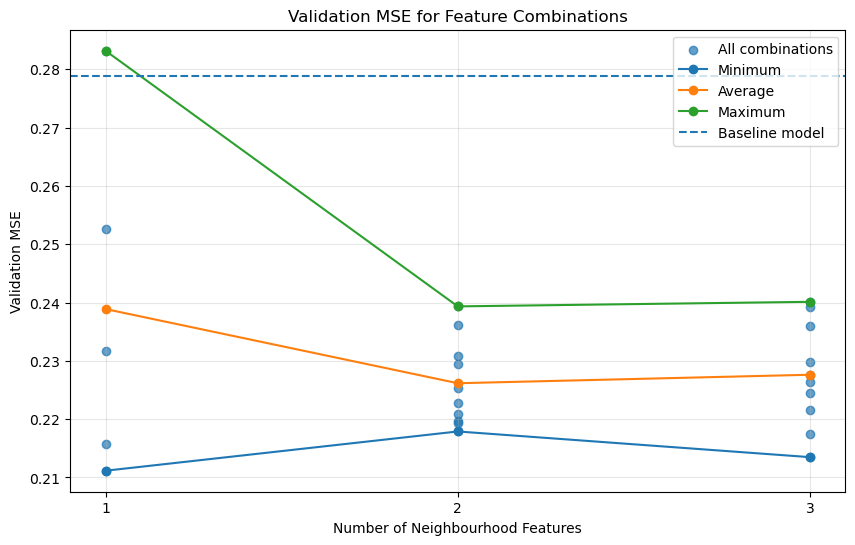

In [13]:
# Plot: Validation MSE vs Number of Neighbourhood Features

import matplotlib.pyplot as plt
import numpy as np


# Compute summary statistics (min, mean, max) for each feature count
summary_df = (
    combo_results_df
    .groupby("num_features")["val_mse"]    
    .agg(["min", "mean", "max"])          
    .reset_index()                      
)


# Scatter plot for all feature combinations
plt.figure(figsize=(10,6))
np.random.seed(26)

plt.scatter(
    combo_results_df["num_features"],   
    combo_results_df["val_mse"],        
    alpha=0.7,
    label="All combinations"
)


# Plot min / average / max validation MSE
plt.plot(
    summary_df["num_features"],
    summary_df["min"],
    marker="o",
    label="Minimum"
)

plt.plot(
    summary_df["num_features"],
    summary_df["mean"],
    marker="o",
    label="Average"
)

plt.plot(
    summary_df["num_features"],
    summary_df["max"],
    marker="o",
    label="Maximum"
)


# Baseline model reference line
plt.axhline(
    y=baseline_val_mse,
    linestyle="--",
    label="Baseline model"
)


# Figure formatting
plt.xlabel("Number of Neighbourhood Features")   
plt.ylabel("Validation MSE")                     
plt.title("Validation MSE for Feature Combinations")  

plt.xticks(sorted(combo_results_df["num_features"].unique()))
plt.legend()                 
plt.grid(True, alpha=0.3)    

plt.show()

From the graph, the lowest validation MSE occurs when **only one neighbourhood feature** is added. Therefore, in the following experiments we only consider adding **one additional neighbourhood feature**.

### Validation MSE for Different Values of \(k\)

This section evaluates how the choice of **\(k\)** affects the usefulness of neighbourhood-based features.

For each value of \(k\), neighbourhood features are recomputed using the corresponding \(k\)-nearest neighbours.  
Each feature is then added to the original dataset individually, and the model is retrained to obtain the **validation MSE**.

The results are stored in a table for comparing how different neighbourhood statistics perform across different values of \(k\).

In [14]:
# Generate results_k_feature_df for Figure 2 (Validation MSE)

from sklearn.neighbors import NearestNeighbors

k_values = [3, 5, 7, 10, 15]

def compute_features_for_k(K):
    knn = NearestNeighbors(n_neighbors=K + 1)
    knn.fit(X_train_raw[['Latitude', 'Longitude']])

    y_train_aligned = y_train.loc[X_train_raw.index].to_numpy()

    # Compute neighbour indices for training and validation sets
    _, idx_train = knn.kneighbors(X_train_raw[['Latitude', 'Longitude']])
    _, idx_val = knn.kneighbors(X_val_raw[['Latitude', 'Longitude']])

    # Remove self from training neighbours
    idx_train = idx_train[:, 1:K+1]
    idx_val = idx_val[:, :K]

    # Convert neighbour indices to price matrices
    train_prices = y_train_aligned[idx_train]
    val_prices = y_train_aligned[idx_val]

    # Compute neighbourhood summary statistics for training and validation sets
    neigh_price_train_k = train_prices.mean(axis=1)
    neigh_price_val_k   = val_prices.mean(axis=1)

    neigh_price_median_train_k = np.median(train_prices, axis=1)
    neigh_price_median_val_k   = np.median(val_prices, axis=1)

    neigh_price_min_train_k = train_prices.min(axis=1)
    neigh_price_min_val_k   = val_prices.min(axis=1)

    neigh_price_max_train_k = train_prices.max(axis=1)
    neigh_price_max_val_k   = val_prices.max(axis=1)

    neigh_price_range_train_k = neigh_price_max_train_k - neigh_price_min_train_k
    neigh_price_range_val_k   = neigh_price_max_val_k - neigh_price_min_val_k

    return {
        "Mean":   (neigh_price_train_k, neigh_price_val_k),
        "Median": (neigh_price_median_train_k, neigh_price_median_val_k),
        "Min":    (neigh_price_min_train_k, neigh_price_min_val_k),
        "Max":    (neigh_price_max_train_k, neigh_price_max_val_k),
        "Range":  (neigh_price_range_train_k, neigh_price_range_val_k),
    }


def run_one_feature(feature_name, f_train, f_val):
    Xtr = X_train_raw.copy()
    Xva = X_val_raw.copy()

    # Add one neighbourhood feature
    Xtr[feature_name] = f_train
    Xva[feature_name] = f_val

    # Re-standardise after adding the new feature
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xva_s = sc.transform(Xva)

    # Train and evaluate
    baseline_model.fit(Xtr_s, y_train)
    val_pred = baseline_model.predict(Xva_s)

    return mean_squared_error(y_val, val_pred)

k_feature_results = []

for K in k_values:
    feature_data = compute_features_for_k(K)

    for feature_name, (f_train, f_val) in feature_data.items():
        val_mse = run_one_feature(feature_name, f_train, f_val)

        k_feature_results.append({
            "k": K,
            "feature": feature_name,
            "val_mse": val_mse
        })

k_feature_results_df = pd.DataFrame(k_feature_results)

print(k_feature_results_df)

     k feature   val_mse
0    3    Mean  0.226609
1    3  Median  0.216555
2    3     Min  0.247268
3    3     Max  0.229717
4    3   Range  0.274513
5    5    Mean  0.219090
6    5  Median  0.214479
7    5     Min  0.257406
8    5     Max  0.232713
9    5   Range  0.282889
10   7    Mean  0.215793
11   7  Median  0.221719
12   7     Min  0.254429
13   7     Max  0.227578
14   7   Range  0.272387
15  10    Mean  0.210448
16  10  Median  0.213539
17  10     Min  0.252699
18  10     Max  0.241687
19  10   Range  0.279358
20  15    Mean  0.218665
21  15  Median  0.215143
22  15     Min  0.266340
23  15     Max  0.246745
24  15   Range  0.269992


### Plot Validation MSE vs Number of Neighbours (k)

This figure shows how the validation MSE changes with different values of **\(k\)** for each single neighbourhood feature.

Each line represents one neighbourhood statistic (mean, median, min, max, range).  
The dashed line indicates the **baseline model performance**, which serves as a reference to evaluate whether neighbourhood features improve the model.

This plot helps identify the most suitable value of \(k\) for constructing neighbourhood-based features.

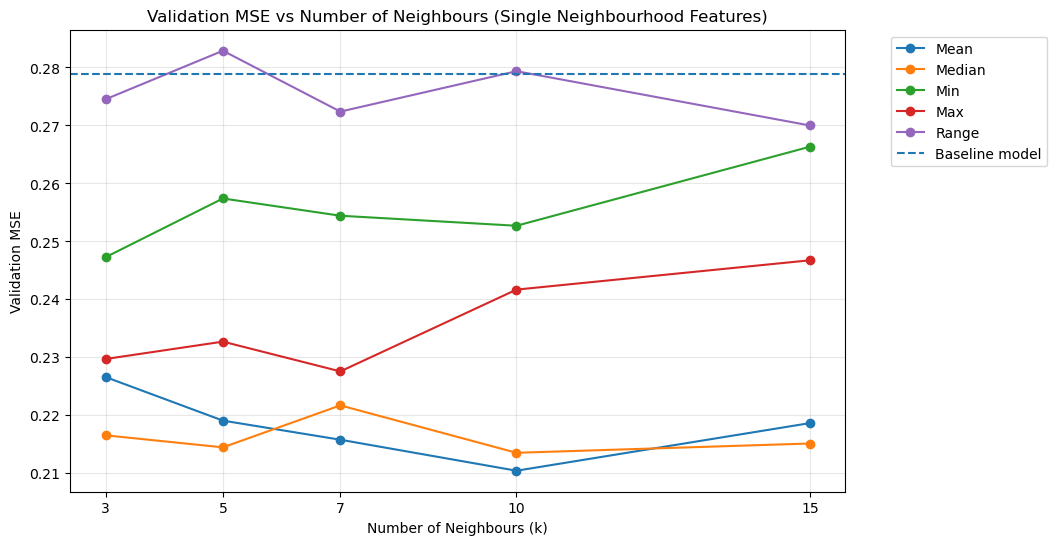

In [15]:
# Figure 2: Validation MSE vs Number of Neighbours (k)
# Single neighbourhood features

plt.figure(figsize=(10, 6))

# Plot validation MSE curves for each single feature
for feature_name in k_feature_results_df["feature"].unique():

    subset = k_feature_results_df[
        k_feature_results_df["feature"] == feature_name
    ].sort_values("k")

    plt.plot(
        subset["k"],
        subset["val_mse"],
        marker="o",
        label=feature_name
    )

# Plot baseline model performance as a reference line
plt.axhline(
    y=baseline_val_mse,
    linestyle="--",
    label="Baseline model"
)

# Figure formatting
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Validation MSE")
plt.title("Validation MSE vs Number of Neighbours (Single Neighbourhood Features)")

plt.xticks(sorted(k_feature_results_df["k"].unique()))
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)

plt.show()

From this plot, the lowest validation MSE is achieved when **k = 10** and the additional neighbourhood feature is the **mean price of neighbouring houses**.

### Final Enhanced Model and Test Set Comparison

In this section, the original training and validation sets are combined to form a final training dataset.

Using the selected best neighbourhood feature(s) and the optimal value of **\(k\)**, the neighbourhood statistics are recomputed on the final training set and added to the input features.  
The enhanced neural network model is then retrained on the combined data and evaluated on the test set.

Finally, the **test MSE** of the enhanced model is compared with that of the baseline model to assess whether neighbourhood-based features improve the final prediction performance.

In [6]:
from sklearn.neighbors import NearestNeighbors

# The above import is already present at the top of the notebook,
# but just for convienience for skipping the plotting cells and 
# calculate the final test MSE after selecting the best feature combination


# 1) Combine original train and validation sets
X_train_final_raw = pd.concat([X_train_raw, X_val_raw], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

# Align indices
X_train_final_raw = X_train_final_raw.sort_index()
y_train_final = y_train_final.loc[X_train_final_raw.index]

# 2) Fit kNN on the new final training set
best_K = 10
knn_final = NearestNeighbors(n_neighbors=best_K + 1)
knn_final.fit(X_train_final_raw[['Latitude', 'Longitude']])

y_train_final_aligned = y_train_final.to_numpy()

# 3) Define function to compute neighbourhood summary features
def neighbour_summary_feature_final(query_df, summary="mean", exclude_self=False):
    _, inds = knn_final.kneighbors(query_df[['Latitude', 'Longitude']])
    values = []

    for row_i, idxs in enumerate(inds):
        if exclude_self:
            idxs = idxs[idxs != row_i]
            idxs = idxs[:best_K]
        else:
            idxs = idxs[:best_K]

        neigh_prices = y_train_final_aligned[idxs]

        if summary == "mean":
            values.append(np.mean(neigh_prices))
        elif summary == "median":
            values.append(np.median(neigh_prices))
        elif summary == "min":
            values.append(np.min(neigh_prices))
        elif summary == "max":
            values.append(np.max(neigh_prices))
        elif summary == "range":
            values.append(np.max(neigh_prices) - np.min(neigh_prices))
        else:
            raise ValueError("summary must be one of: mean, median, min, max, range")

    return np.array(values)

# 4) Compute only the selected best features
feature_map = {
    "Mean": "mean",
    "Median": "median",
    "Min": "min",
    "Max": "max",
    "Range": "range"
}

best_features = ["Mean"]   # 输入最终选出来的组合

train_final_feature_values = {}
test_feature_values = {}

for feat in best_features:
    summary_name = feature_map[feat]
    train_final_feature_values[feat] = neighbour_summary_feature_final(
        X_train_final_raw, summary=summary_name, exclude_self=True
    )
    test_feature_values[feat] = neighbour_summary_feature_final(
        X_test_raw, summary=summary_name, exclude_self=False
    )


# 5) Add selected feature(s) to the final dataset
X_train_enh_final_raw = X_train_final_raw.copy()
X_test_enh_final_raw = X_test_raw.copy()

for feat in best_features:
    col_name = f"NeighbourPrice{feat}"
    X_train_enh_final_raw[col_name] = train_final_feature_values[feat]
    X_test_enh_final_raw[col_name] = test_feature_values[feat]


# 6) Train the final enhanced model
scaler_enh_final = StandardScaler()

X_train_enh_final = pd.DataFrame(
    scaler_enh_final.fit_transform(X_train_enh_final_raw),
    columns=X_train_enh_final_raw.columns,
    index=X_train_enh_final_raw.index
)

X_test_enh_final = pd.DataFrame(
    scaler_enh_final.transform(X_test_enh_final_raw),
    columns=X_test_enh_final_raw.columns,
    index=X_test_enh_final_raw.index
)

model_enh_final = MLPRegressor(
    hidden_layer_sizes=(128, 32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=800,
    early_stopping=False,
    random_state=26
)

model_enh_final.fit(X_train_enh_final, y_train_final)
test_pred_enh_final = model_enh_final.predict(X_test_enh_final)
enhanced_test_mse_final = mean_squared_error(y_test, test_pred_enh_final)

# 7) Final comparison
print("Final Baseline Test MSE:", baseline_test_mse_final)
print("Final Enhanced Test MSE:", enhanced_test_mse_final)
print("Delta Test MSE (Enhanced - Baseline):", enhanced_test_mse_final - baseline_test_mse_final)

Final Baseline Test MSE: 0.24851482842267858
Final Enhanced Test MSE: 0.18047048234110835
Delta Test MSE (Enhanced - Baseline): -0.06804434608157023


PART FOUR

Comparison of the baseline_final_model and model_enh_final
   - Determine whether the final Baseline and Enhanced models exhibit underfitting or overfitting
   - Compare the percentage improvements in MSE between the final Baseline and Enhanced models
   - Examine the impact of different house prices on the predictive accuracy of the final Baseline and Enhanced models

## Validation-based Overfitting / Underfitting Assessment

In this section, the final **Model 1** and **Model 2** are re-run on the training set and validation set in order to examine whether either model shows signs of **underfitting** or **overfitting**.

The main idea is to compare the **training MSE** and **validation MSE** of each model, rather than relying on the test set. The validation set is more appropriate for checking generalisation behaviour during model development, while the test set should mainly be reserved for final performance reporting.

Two types of evidence are used in this check:

- **The validation/train MSE ratio** is used as a simple quantitative indicator of the generalisation gap.  
  - If the ratio is too large, it may suggest **overfitting**, because the model performs much better on the training set than on the validation set.  
  - If the ratio is very close to 1, the model has only a small generalisation gap; combined with the absolute error level, this can further help judge whether the model may be **underfitting**.

- **The train-versus-validation MSE chart** and **learning curves** are used as visual evidence.  
  - The bar chart helps compare the final training and validation errors for the two models directly.  
  - The learning curves help check whether the optimisation converges stably and whether there is any obvious divergence between training performance and validation performance.

Together, the ratio and the figures provide a clear validation-stage diagnosis of whether Model 1 and Model 2 are reasonably fitted.

## 1. Validation-based baseline model

First, the final selected baseline model is reconstructed using the same architecture and settings as the previously chosen baseline configuration.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors

# ------------------------------------------------------------
# 1. Validation-stage baseline model
# 验证阶段：基准模型
# ------------------------------------------------------------

scaler_base_valcheck = StandardScaler()
# Create a scaler to standardise features
# 创建标准化器用于特征标准化

X_train_base_valcheck = scaler_base_valcheck.fit_transform(X_train_raw)
# Fit scaler on training data and transform training features
# 用训练数据拟合scaler并转换训练特征

X_val_base_valcheck   = scaler_base_valcheck.transform(X_val_raw)
# Apply the same transformation to validation data
# 使用同样的标准化参数转换验证数据

baseline_valcheck_model = MLPRegressor(
    hidden_layer_sizes=(128, 32),  # neural network structure / 神经网络结构
    activation='tanh',             # activation function / 激活函数
    solver='adam',                 # optimiser / 优化算法
    learning_rate_init=1e-3,       # learning rate / 学习率
    max_iter=800,                  # maximum training iterations / 最大训练轮数
    early_stopping=False,          # disable internal early stopping / 不启用早停
    random_state=26                # ensure reproducibility / 保证结果可复现
)

baseline_valcheck_model.fit(X_train_base_valcheck, y_train)
# Train the baseline neural network
# 训练基准神经网络模型

baseline_train_pred_valcheck = baseline_valcheck_model.predict(X_train_base_valcheck)
# Predictions on training data
# 对训练数据进行预测

baseline_val_pred_valcheck   = baseline_valcheck_model.predict(X_val_base_valcheck)
# Predictions on validation data
# 对验证数据进行预测

m1_train_mse_val = mean_squared_error(y_train, baseline_train_pred_valcheck)
# Training Mean Squared Error
# 训练集均方误差

m1_val_mse       = mean_squared_error(y_val, baseline_val_pred_valcheck)
# Validation Mean Squared Error
# 验证集均方误差

# training loss curve (approximate MSE)
# 训练过程loss曲线（近似MSE）
train_loss_curve_m1_val = np.array(baseline_valcheck_model.loss_curve_) * 2

## 2. Validation-based enhanced model

Next, the final selected enhanced model is re-trained using the same training-validation framework.

In [ ]:
# ------------------------------------------------------------
# 2. Validation-stage enhanced model
# 验证阶段：增强模型（加入邻域价格特征）
# ------------------------------------------------------------

best_K_valcheck = best_K
# Use previously selected optimal K for neighbour search
# 使用之前确定的最佳邻居数量K

knn_valcheck = NearestNeighbors(n_neighbors=best_K_valcheck + 1)
# Create KNN model to find spatial neighbours
# 创建KNN模型用于寻找空间邻居

knn_valcheck.fit(X_train_raw[['Latitude', 'Longitude']])
# Fit KNN using training coordinates
# 使用训练数据的经纬度训练KNN

y_train_aligned_valcheck = y_train.loc[X_train_raw.index].to_numpy()
# Align training target values with feature indices
# 确保训练标签与特征索引对齐

# training neighbours (remove self)
# 查找训练样本邻居（去掉自身）
_, idx_train_valcheck = knn_valcheck.kneighbors(X_train_raw[['Latitude', 'Longitude']])
idx_train_valcheck = idx_train_valcheck[:, 1:best_K_valcheck + 1]

# validation neighbours (query against training only)
# 查找验证样本邻居（只在训练集中查询）
_, idx_val_valcheck = knn_valcheck.kneighbors(X_val_raw[['Latitude', 'Longitude']])
idx_val_valcheck = idx_val_valcheck[:, :best_K_valcheck]

train_prices_valcheck = y_train_aligned_valcheck[idx_train_valcheck]
# Prices of neighbouring houses for training samples
# 训练样本邻居房价

val_prices_valcheck   = y_train_aligned_valcheck[idx_val_valcheck]
# Prices of neighbouring houses for validation samples
# 验证样本邻居房价

# neighbour mean price feature
# 邻居平均房价特征
neigh_mean_train_valcheck = train_prices_valcheck.mean(axis=1)
neigh_mean_valcheck       = val_prices_valcheck.mean(axis=1)

X_train_enh_valcheck_raw = X_train_raw.copy()
X_val_enh_valcheck_raw   = X_val_raw.copy()

X_train_enh_valcheck_raw["NeighbourPriceMean"] = neigh_mean_train_valcheck
# Add neighbour price feature to training set
# 向训练集添加邻居房价特征

X_val_enh_valcheck_raw["NeighbourPriceMean"]   = neigh_mean_valcheck
# Add neighbour price feature to validation set
# 向验证集添加邻居房价特征

scaler_enh_valcheck = StandardScaler()
# Standardise enhanced feature set
# 对增强后的特征再次进行标准化

X_train_enh_valcheck = scaler_enh_valcheck.fit_transform(X_train_enh_valcheck_raw)
X_val_enh_valcheck   = scaler_enh_valcheck.transform(X_val_enh_valcheck_raw)

enhanced_valcheck_model = MLPRegressor(
    hidden_layer_sizes=(128, 32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=800,
    early_stopping=False,
    random_state=26
)

enhanced_valcheck_model.fit(X_train_enh_valcheck, y_train)
# Train enhanced model
# 训练增强模型

enh_train_pred_valcheck = enhanced_valcheck_model.predict(X_train_enh_valcheck)
enh_val_pred_valcheck   = enhanced_valcheck_model.predict(X_val_enh_valcheck)

m2_train_mse_val = mean_squared_error(y_train, enh_train_pred_valcheck)
m2_val_mse       = mean_squared_error(y_val, enh_val_pred_valcheck)

# training loss curve (approximate MSE)
# 记录训练损失曲线
train_loss_curve_m2_val = np.array(enhanced_valcheck_model.loss_curve_) * 2

## 3. Diagnosis based on the validation/train ratio

A simple validation-stage diagnostic rule is used here based on the ratio:

**Ratio = Validation MSE / Train MSE**

This ratio provides a direct summary of the gap between training performance and validation performance.

- If the ratio is **too large** (for example, above 1.5), this suggests that validation performance is much worse than training performance, which may indicate **overfitting**.
- If the ratio is **very close to 1** (for example, below 1.1), then the generalisation gap is small. In that case, if both errors are still relatively high, the model may be **underfitting**.
- If the ratio falls in a moderate range, this usually suggests a more reasonable balance between fitting and generalisation.

Therefore, the ratio is used to support the judgement of whether the model is underfitting, overfitting, or reasonably fitted.

In [ ]:
# ------------------------------------------------------------
# 3. Simple diagnosis based on validation / train ratio
# 基于验证误差 / 训练误差比例的简单诊断
# ------------------------------------------------------------

def diagnose_validation(model_name, train_mse, val_mse, threshold_ratio=1.5):
    # Function to diagnose overfitting or underfitting
    # 根据误差比例判断过拟合或欠拟合

    ratio = val_mse / train_mse if train_mse > 0 else float('inf')
    # Compute validation/train error ratio
    # 计算验证误差与训练误差的比例

    print(f"\n{'='*60}")
    print(model_name)
    print(f"{'='*60}")
    print(f"Train MSE             : {train_mse:.4f}")
    print(f"Validation MSE        : {val_mse:.4f}")
    print(f"Validation/Train Ratio: {ratio:.3f}")

    if ratio > threshold_ratio:
        print("Diagnosis: possible overfitting (validation error notably exceeds training error)")
    elif ratio < 1.1:
        print("Diagnosis: small generalisation gap — possible underfitting if both errors remain relatively high compared with earlier configurations")
    else:
        print("Diagnosis: moderate generalisation gap / reasonable fit")

    print(f"{'='*60}")


diagnose_validation("Model 1 — Baseline (validation stage)", m1_train_mse_val, m1_val_mse)
# Run diagnosis for baseline model
# 对基准模型进行诊断

diagnose_validation("Model 2 — Enhanced (validation stage)", m2_train_mse_val, m2_val_mse)
# Run diagnosis for enhanced model
# 对增强模型进行诊断


## 4. Visual comparison of training and validation MSE

The following bar chart compares the final **training MSE** and **validation MSE** for Model 1 and Model 2.

This figure provides a direct visual comparison of:

- how well each model fits the training data,
- how well each model generalises to the validation data,
- and how large the train-validation gap is for each model.

A small difference between the two bars for the same model suggests a limited generalisation gap, while a much larger validation bar may indicate overfitting.

In [ ]:
# ------------------------------------------------------------
# 4. Visualisation 1 — Train vs Validation MSE
# 可视化1：训练误差 vs 验证误差
# ------------------------------------------------------------

labels = ['Model 1\n(Baseline)', 'Model 2\n(Enhanced)']
# Labels for models
# 模型标签

train_mses_val = [m1_train_mse_val, m2_train_mse_val]
# Training errors
# 训练误差

val_mses       = [m1_val_mse, m2_val_mse]
# Validation errors
# 验证误差

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
# Create bar chart
# 创建柱状图

bars1 = ax.bar(x - width/2, train_mses_val, width, label='Train MSE', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, val_mses, width, label='Validation MSE', color='darkorange', alpha=0.85)

ax.set_ylabel('MSE')
ax.set_title('Train vs Validation MSE — Model 1 and Model 2')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for bar, val in zip(bars1, train_mses_val):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
# Display values on training bars
# 在训练柱状图上显示数值

for bar, val in zip(bars2, val_mses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
# Display values on validation bars
# 在验证柱状图上显示数值

plt.tight_layout()
plt.show()

## 5. Learning curves

The learning curves below show how the training loss evolves over epochs for both models.

These curves are useful for checking whether:

- the optimiser converges in a stable way,
- training continues to improve over time,
- and the final training performance remains reasonably close to the validation performance.

The horizontal lines indicate the final **training MSE** and **validation MSE**, making it easier to compare the final generalisation gap together with the optimisation process.

If the training curve converges smoothly and the final validation MSE does not rise far above the training MSE, this provides further evidence against severe overfitting. On the other hand, if the training loss decreases only to a limited extent and both the final training and validation MSE remain relatively high, this may indicate underfitting.

In [ ]:
# ------------------------------------------------------------
# 5. Visualisation 2 — Learning Curves
# 可视化2：学习曲线
# ------------------------------------------------------------

print(f"Model 1 actual training epochs: {len(train_loss_curve_m1_val)}")
print(f"Model 2 actual training epochs: {len(train_loss_curve_m2_val)}")
print("Note: fewer epochs than max_iter indicate optimiser convergence before max_iter.")
# Print actual number of training epochs
# 打印实际训练轮数

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

global_min = min(
    train_loss_curve_m1_val.min(),
    train_loss_curve_m2_val.min(),
    m1_val_mse,
    m2_val_mse
)

global_max = max(
    train_loss_curve_m1_val.max(),
    train_loss_curve_m2_val.max(),
    m1_val_mse,
    m2_val_mse
)
# Set unified y-axis scale
# 统一y轴范围

for ax, lc_tr, final_train_mse, final_val_mse, title in zip(
    axes,
    [train_loss_curve_m1_val, train_loss_curve_m2_val],
    [m1_train_mse_val, m2_train_mse_val],
    [m1_val_mse, m2_val_mse],
    ['Model 1 — Baseline (validation stage)', 'Model 2 — Enhanced (validation stage)']
):

    epochs = range(1, len(lc_tr) + 1)

    ax.plot(epochs, lc_tr, label='Train MSE', color='steelblue')
    # Plot training learning curve
    # 绘制训练误差曲线

    ax.axhline(
        y=final_train_mse,
        color='steelblue',
        linestyle=':',
        linewidth=1.2,
        label=f'Final Train MSE = {final_train_mse:.4f}'
    )

    ax.axhline(
        y=final_val_mse,
        color='darkorange',
        linestyle='--',
        linewidth=1.2,
        label=f'Final Validation MSE = {final_val_mse:.4f}'
    )
    # Horizontal lines showing final errors
    # 水平线表示最终训练误差与验证误差

    ax.set_ylim(global_min * 0.9, global_max * 1.05)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Learning Curves — Validation-stage Generalisation Check', fontsize=13)
plt.tight_layout()
plt.show()

Conclusion

From the validation-stage results, both Model 1 and Model 2 appear to be reasonably fitted.

For both models, the validation/train MSE ratio stays below the heuristic overfitting warning threshold of 1.5, suggesting that there is no obvious sign of overfitting at the validation stage.

From the Train vs Validation MSE plot, both models show generally acceptable MSE performance on the training and validation sets. From the Learning Curves plot, the training loss of both models decreases steadily with epoch and gradually converges, indicating a stable training process without obvious abnormal fluctuations or divergence. Taken together, these two graphs also provide no clear evidence of underfitting.

Overall, based on the validation/train MSE ratio and the two graphs, both Model 1 and Model 2 show reasonable generalisation performance at the validation stage.

In [7]:
# ===============================
# Improvement percentage
# ===============================

improvement = (baseline_test_mse_final - enhanced_test_mse_final) / baseline_test_mse_final

print("\n=== Improvement Analysis ===")
print(f"Baseline Test MSE: {baseline_test_mse_final:.4f}")
print(f"Best Enhanced Test MSE: {enhanced_test_mse_final:.4f}")
print(f"Improvement Percentage: {improvement*100:.2f}%")


=== Improvement Analysis ===
Baseline Test MSE: 0.2485
Best Enhanced Test MSE: 0.1805
Improvement Percentage: 27.38%


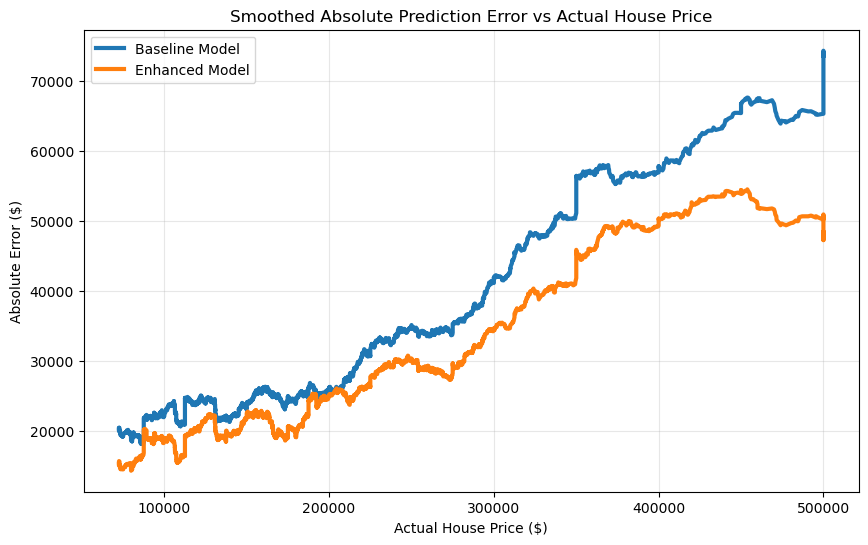

In [21]:
# ============================================================
# Absolute Error vs Actual House Price 
# Baseline Model vs Enhanced Model
# ============================================================
# 图像说明：
# x轴：真实房价 (单位：美元 $)
# y轴：绝对误差 |Prediction - Actual| (单位：美元 $)
# California Housing 数据集中的房价单位是 10 万美元
# 因此需要乘以 100000 转换为真实美元价格
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Extract actual house prices
# 提取真实房价
# 数据集中房价单位是 100,000 美元
# 因此需要乘以 100000 转换为真实美元
# ------------------------------------------------------------

actual_price = y_test.to_numpy() * 100000


# ------------------------------------------------------------
# 2. Convert predictions to dollars
# 将模型预测值也转换为美元单位
# ------------------------------------------------------------

baseline_pred_dollar = baseline_test_pred * 100000
enhanced_pred_dollar = test_pred_enh_final * 100000


# ------------------------------------------------------------
# 3. Compute absolute errors
# 计算绝对误差 |prediction - actual|
# ------------------------------------------------------------

baseline_abs_error = np.abs(baseline_pred_dollar - actual_price)
enhanced_abs_error = np.abs(enhanced_pred_dollar - actual_price)


# ------------------------------------------------------------
# 4. Build dataframe for sorting
# 构建 dataframe 并按真实房价排序
# ------------------------------------------------------------

df_plot = pd.DataFrame({
    "ActualPrice": actual_price,
    "BaselineError": baseline_abs_error,
    "EnhancedError": enhanced_abs_error
})

df_plot = df_plot.sort_values("ActualPrice")


# ------------------------------------------------------------
# 5. Rolling average smoothing
# 滚动平均平滑曲线
# ------------------------------------------------------------

window = 300
# window = 300 means each rolling average uses the current point
# and the previous 299 observations (300 points in total)
# window = 300 表示每个滚动平均使用当前点和前面 299 个数据
# 一共 300 个点来计算平均值

baseline_smooth = df_plot["BaselineError"].rolling(window=300).mean()
enhanced_smooth = df_plot["EnhancedError"].rolling(window=300).mean()


# ------------------------------------------------------------
# # 6. Plot smoothed trends
# 繪製平滑趨勢線
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.plot(
    df_plot["ActualPrice"],
    baseline_smooth,
    linewidth=3,
    label="Baseline Model"
)

plt.plot(
    df_plot["ActualPrice"],
    enhanced_smooth,
    linewidth=3,
    label="Enhanced Model"
)


# ------------------------------------------------------------
# 7. Formatting
# 图像设置
# ------------------------------------------------------------

plt.xlabel("Actual House Price ($)")
plt.ylabel("Absolute Error ($)")
plt.title("Smoothed Absolute Prediction Error vs Actual House Price")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

PART FIVE

Analysis of the California Housing Dataset (limitation Code Section)
   - Investigate the relationship between house prices and their frequency of occurrence in the dataset
   - Examine instances where the same latitude and longitude coordinates appear multiple times in the dataset
   - Examine the distribution density of data across different regions in the dataset

## Investigate the relationship between house prices and their frequency of occurrence in the dataset

By examining the relationship between the magnitude of house prices and their frequency of occurrence within the dataset, we can determine whether unusually high or low prices might have a disproportionate impact on the MSE, thereby affecting the interpretation of the model’s performance.

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


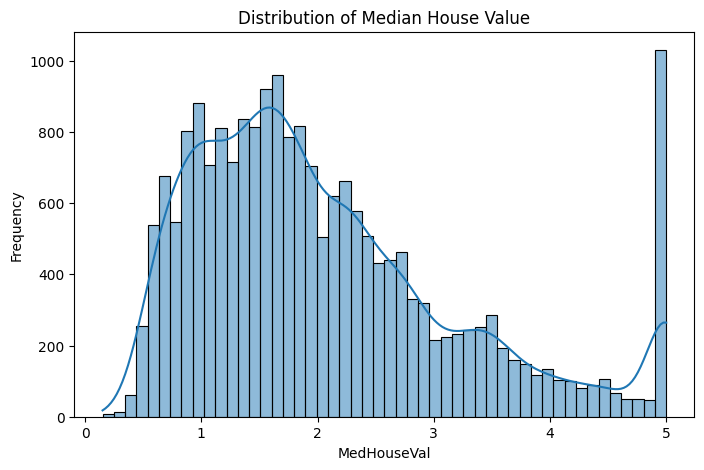

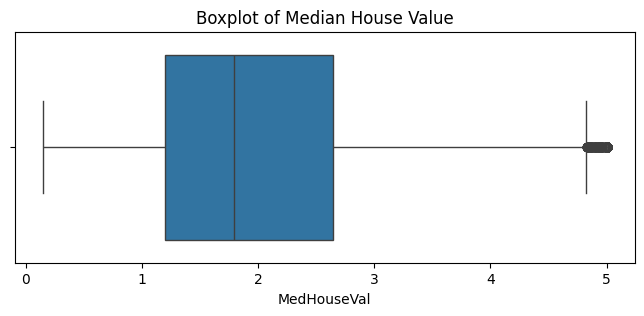

Top 10 highest house values:
10667    5.00001
16916    5.00001
16946    5.00001
8877     5.00001
8878     5.00001
8879     5.00001
16941    5.00001
16940    5.00001
16939    5.00001
16938    5.00001
Name: MedHouseVal, dtype: float64


In [13]:
#Explore the relationship between the frequency of occurrence and the high or low prices of houses in the dataset.
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Print the statistical information of the basic price.
print(y.describe())

# 2. Histogram
plt.figure(figsize=(8, 5))
sns.histplot(y, bins=50, kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("MedHouseVal")
plt.ylabel("Frequency")
plt.show()

# 3. Boxplot
plt.figure(figsize=(8, 3))
sns.boxplot(x=y)
plt.title("Boxplot of Median House Value")
plt.xlabel("MedHouseVal")
plt.show()

# 4. Top 10 highest values
print("Top 10 highest house values:")
print(y.sort_values(ascending=False).head(10))

The house price distribution plot shows that both the magnitude and frequency of house prices generally follow a normal distribution, with the majority of prices concentrated in the lower to middle ranges, whilst a distinct peak in frequency is observed near the maximum value of 5. This indicates that the house price variable in the dataset exhibits a capped value phenomenon, whereby prices exceeding a certain threshold are uniformly recorded as the maximum value. However, the loss function used in this model evaluation relies solely on the mean squared error (MSE). As MSE is sensitive to large errors and outliers, abnormally high property prices and associated errors may exert a disproportionate influence on the MSE, thereby affecting the interpretation of the model’s performance.

## Examine instances where the same latitude and longitude coordinates appear multiple times in the dataset

Determine whether the KNN method suffers from instability in neighbour selection by examining whether there are duplicate latitude and longitude coordinates in the data.

Number of unique coordinates: 12590
Number of duplicated coordinate locations: 4353
Top duplicated coordinates:
      Longitude  Latitude  count
936     -122.41     37.80     15
907     -122.42     37.80     11
865     -122.44     37.78     11
883     -122.43     37.77     10
902     -122.42     37.75     10
1310    -122.27     37.85     10
931     -122.41     37.75     10
866     -122.44     37.79     10
867     -122.44     37.80     10
881     -122.43     37.75     10


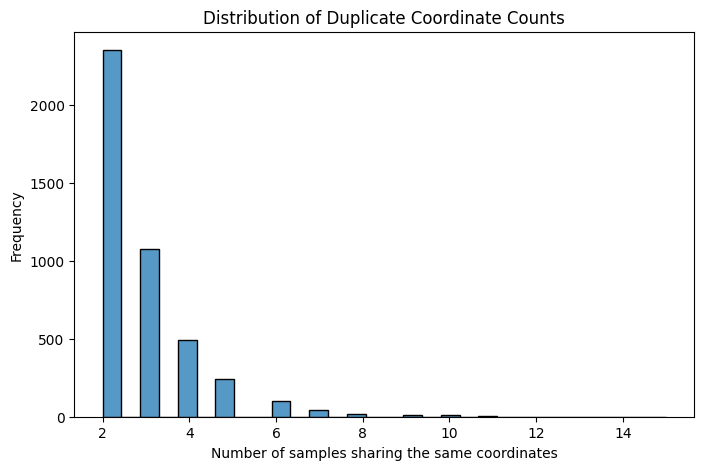

In [14]:
#Explore the situation where the same latitude and longitude appear repeatedly in the dataset.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 组合经纬度
# Combine Latitude and Longitude
coords = X[['Longitude', 'Latitude']].copy()

# 统计每个坐标出现次数
#Count the occurrence of each coordinate.
coord_counts = (
    coords.groupby(['Longitude', 'Latitude'])
    .size()
    .reset_index(name='count')
)

# 只保留重复坐标（count > 1）
# Only retain the coordinates that are repeated (where count is greater than 1)
duplicate_coords = coord_counts[coord_counts['count'] > 1].copy()

print("Number of unique coordinates:", len(coord_counts))
print("Number of duplicated coordinate locations:", len(duplicate_coords))
print("Top duplicated coordinates:")
print(duplicate_coords.sort_values('count', ascending=False).head(10))

plt.figure(figsize=(8, 5))
sns.histplot(duplicate_coords['count'], bins=30, edgecolor='black')
plt.title('Distribution of Duplicate Coordinate Counts')
plt.xlabel('Number of samples sharing the same coordinates')
plt.ylabel('Frequency')
plt.show()

This figure reveals that a large number of samples in the dataset share exactly the same geographical coordinates. Of the 20,640 samples, 4,353 coordinate locations contain multiple observations, with some coordinates corresponding to as many as 15 records. This suggests that a single coordinate point in the dataset may represent a small area rather than a single property.

When constructing neighbourhood features using KNN, if the number of samples corresponding to a particular location exceeds the selected k-value, the distances between these samples will be identical. In such cases, scikit-learn may select only the top k neighbours based on internal sorting during the neighbour selection process, thereby overlooking some samples with identical distances. This situation may lead to a certain degree of instability in the calculation of neighbourhood features and may affect the stability of the model training results.

## Examine the distribution density of data across different regions in the dataset

We analyse the suitability of the KNN method by examining the density of data across different regions within the dataset.

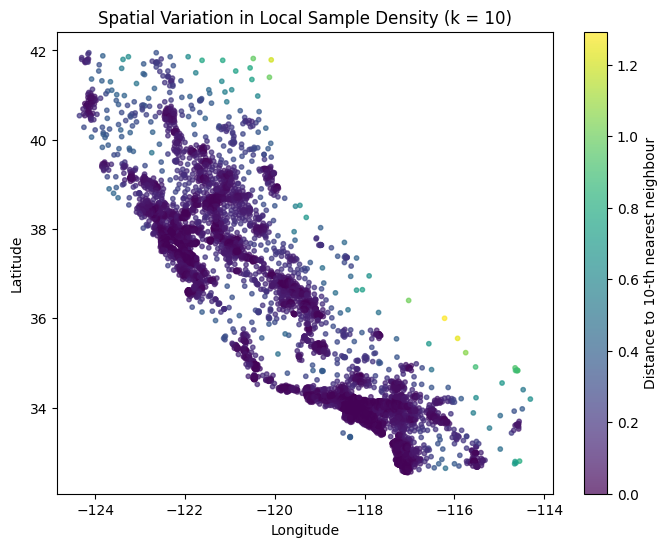

In [15]:
#Explore the density of data in each region of the dataset
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# 只用坐标做 KNN
# Use only coordinates for KNN
coords_array = X[['Longitude', 'Latitude']].values

k = 10
knn = NearestNeighbors(n_neighbors=k+1)  # +1 because first neighbor is itself
knn.fit(coords_array)

distances, _ = knn.kneighbors(coords_array)

# 第 k 个邻居的距离（跳过自己）
#The distance of the kth neighbor (excluding oneself)
kth_dist = distances[:, k]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X['Longitude'],
    X['Latitude'],
    c=kth_dist,
    s=10,
    alpha=0.7
)
plt.colorbar(scatter, label=f'Distance to {k}-th nearest neighbour')
plt.title(f'Spatial Variation in Local Sample Density (k = {k})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

An analysis of the spatial distribution density of the data reveals significant variations in density across different regions. Sample distribution is relatively dense in coastal urban areas (such as Los Angeles and the San Francisco Bay Area), whilst it is comparatively sparse in certain inland regions. As can be seen from the figure, in dense areas, the distance to the kth neighbour is small, whereas in sparse areas, this distance is significantly greater. This implies that when constructing neighbourhood features using a fixed k-value, the actual spatial scope corresponding to different samples may vary considerably.

In areas with a high density of samples, neighbourhood features primarily reflect very localised house price information; whereas in areas with a low density of samples, neighbourhood features may incorporate house price data from much greater distances, thereby reducing the representativeness of the neighbourhood features for local house price structures. This imbalance in spatial density may affect the stability of KNN neighbourhood features and have a certain impact on the model’s predictive performance.